# Logistic Regression from Scratch — Class Notes

Same GD loop as linear regression — but two things change:
1. **Activation**: `step()` → `sigmoid()` (smooth, differentiable)
2. **Loss**: MSE → **Log-loss** (cross-entropy)

---

| | Linear Regression | Perceptron | Logistic Regression |
|---|---|---|---|
| Activation | None (identity) | `step()` hard 0/1 | `sigmoid()` smooth 0–1 |
| Output | Continuous value | Binary class | Probability |
| Loss | MSE | Mistake-driven | Log-loss |
| Update | Always (GD) | Only on mistakes | Always (GD) |
| Decision boundary | N/A | Linear | Linear |

## Step 0 — Imports & Data

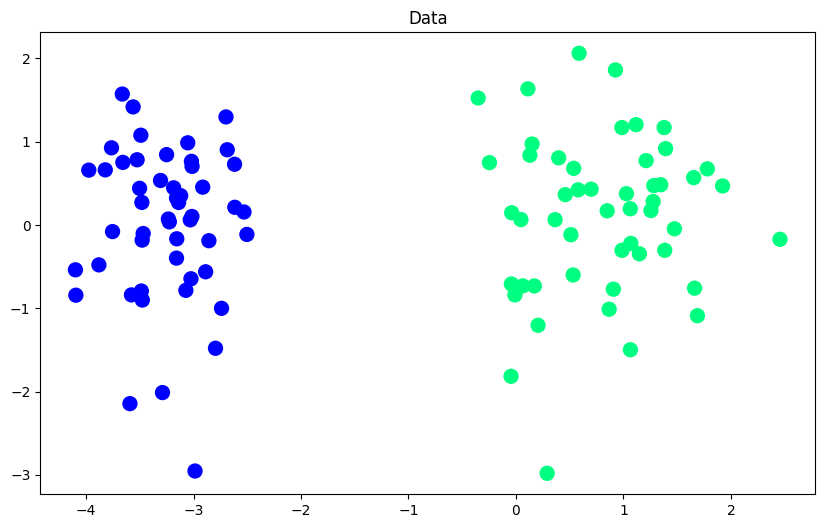

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=41,
    hypercube=False,
    class_sep=20       # large separation → clearly linearly separable
)

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.title('Data')
plt.show()

## Step 1 — Sigmoid Function

Maps any real number z to a **probability between 0 and 1**.

```
sigmoid(z) = 1 / (1 + e^(-z))

z = +∞  →  sigmoid ≈ 1.0   (confident class 1)
z =  0  →  sigmoid = 0.5   (the decision boundary)
z = -∞  →  sigmoid ≈ 0.0   (confident class 0)
```

Why not `step()`? The step function has zero gradient everywhere — GD can't learn from it.
Sigmoid is smooth and differentiable, so GD works.

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
    # works on scalars AND numpy arrays (vectorised automatically)

## Step 2 — Logistic Regression with Gradient Descent

### The update rule

The gradient of **log-loss** (cross-entropy) w.r.t. weights simplifies beautifully:

```
∂L/∂w = (1/n) · Xᵀ · (ŷ − y)      ← gradient of log-loss

w ← w − lr · ∂L/∂w
  = w − lr · (1/n) · Xᵀ(ŷ − y)
  = w + lr · (1/n) · Xᵀ(y − ŷ)    ← written with (y − ŷ) → sign flips to +
```

So `weights = weights + lr * dot((y - y_hat), X) / n` — the **+** is correct here.

### Why `np.dot((y - y_hat), X)` and not `np.dot(X, (y - y_hat))`?

```
(y - y_hat) shape: (100,)
X shape:           (100, 3)

np.dot((100,), (100, 3)) → (3,)   ← one gradient per weight ✓
np.dot((100, 3), (100,)) → error  ✗
```

In [3]:
def gd(X, y):

    # ── Bias trick: prepend column of 1s ────────────────────────────
    X = np.insert(X, 0, 1, axis=1)
    # X shape: (100, 2) → (100, 3)
    # weights = [w₀, w₁, w₂]  where w₀ = intercept (bias)

    weights = np.ones(X.shape[1])   # [1., 1., 1.]
    lr = 0.5

    for i in range(5000):

        # ── Forward pass: compute probabilities ─────────────────────
        y_hat = sigmoid(np.dot(X, weights))
        # np.dot(X, weights) → (100,)  z-scores for all samples
        # sigmoid(...)       → (100,)  probabilities in [0, 1]

        # ── Gradient update (batch GD on log-loss) ──────────────────
        weights = weights + lr * (np.dot((y - y_hat), X) / X.shape[0])
        # (y - y_hat)      → (100,)   error per sample
        # np.dot(..., X)   → (3,)     sum of error × each feature column
        # / X.shape[0]     → divide by n = mean gradient
        # + lr (not - lr)  → because log-loss gradient uses (y - ŷ) with flipped sign

    return weights[1:], weights[0]   # coef_, intercept_

In [4]:
coef_, intercept_ = gd(X, y)
print('coef_:     ', coef_)
print('intercept_:', intercept_)

coef_:      [4.83926872 0.21182255]
intercept_: 5.83338864905325


## Step 3 — Decision Boundary (same algebra as Perceptron)

The boundary is where `sigmoid(z) = 0.5` → which means `z = 0`:

```
w₀ + w₁·x₁ + w₂·x₂ = 0
x₂ = −(w₁/w₂)·x₁ − (w₀/w₂)
x₂ =       m·x₁   +   b
```

In [5]:
# Our scratch model
m = -(coef_[0] / coef_[1])
b = -(intercept_ / coef_[1])

x_input = np.linspace(-3, 3, 100)
y_input = m * x_input + b

## Step 4 — Compare with sklearn Logistic Regression

### ConvergenceWarning fix
The default `max_iter=100` is too low for the `sag` solver. Set `max_iter=10000` to silence the warning.

In [6]:
from sklearn.linear_model import LogisticRegression

lor = LogisticRegression(
    penalty='none',     # no L1/L2 regularisation → matches our scratch version
    solver='sag',       # Stochastic Average Gradient — a fast GD variant
    max_iter=10000      # fix for ConvergenceWarning (default 100 is too low for sag)
)
lor.fit(X, y)

print('sklearn coef_:     ', lor.coef_)
print('sklearn intercept_:', lor.intercept_)

# lor.coef_ shape = (1, n_features) for binary → need [0][0] and [0][1]
m1 = -(lor.coef_[0][0] / lor.coef_[0][1])
b1 = -(lor.intercept_ / lor.coef_[0][1])

x_input1 = np.linspace(-3, 3, 100)
y_input1 = m1 * x_input1 + b1

InvalidParameterError: The 'penalty' parameter of LogisticRegression must be a str among {'elasticnet', 'l1', 'l2'} or None. Got 'none' instead.

## Step 5 — Plot Both Boundaries

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(x_input,  y_input,  color='red',   linewidth=3, label='Our GD (scratch)')
plt.plot(x_input1, y_input1, color='black', linewidth=3, label='sklearn LogisticRegression')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.ylim(-3, 2)
plt.legend()
plt.title('Scratch GD vs sklearn — decision boundaries')
plt.show()
# Both lines should nearly overlap — our GD arrived at the same answer as sklearn

---

## Summary

| Concept | Detail |
|---|---|
| `sigmoid(z)` | Maps z → probability in (0, 1). Boundary at z = 0 → prob = 0.5 |
| Bias trick | `np.insert(X, 0, 1, axis=1)` → w[0] becomes intercept |
| Update rule | `w += lr · dot((y − ŷ), X) / n` — note **+** not **−** |
| Why **+** | Log-loss gradient = Xᵀ(ŷ−y)/n · subtract negative = add positive |
| Boundary | Solve `w·x = 0` for x₂: slope `m = −w₁/w₂`, intercept `b = −w₀/w₂` |
| `penalty='none'` | Turns off sklearn's default L2 regularisation so it matches our scratch version |
| `max_iter=10000` | Fixes ConvergenceWarning with the `sag` solver |

### Perceptron vs Logistic Regression — one-line difference

```python
# Perceptron
y_hat = step(np.dot(X[j], weights))           # hard 0 or 1
weights += lr * (y[j] - y_hat) * X[j]         # updates only on mistakes

# Logistic Regression
y_hat = sigmoid(np.dot(X, weights))            # soft probability
weights += lr * np.dot((y - y_hat), X) / n    # always updates (batch GD)
```